# ILUSTR 1 — Błąd bezwzględny i względny: dwie miary niedokładności i kiedy którą stosować

Pokrywa: slajdy 2–10 prezentacji ZW_1 oraz sekcję „Błąd względny i bezwzględny" konspektu ZW_1.

**Błąd bezwzględny** $\Delta x = |\tilde{x} - x|$ mówi, *o ile* się pomyłiliśmy — w jednostkach
mierzonej wielkości (złotych, woltach, metrach). **Błąd względny** $\delta x = \Delta x / x$
mówi, *jak bardzo* się pomyłiliśmy w stosunku do samej wartości — jest bezwymiarowy, więc
nadaje się do porównywania jakości oszacowań w zupełnie różnych skalach.

W tym notatniku przekonujemy się liczbowo, że żadnej z tych miar nie da się używać samodzielnie:
- ta sama jakość (błąd względny) może oznaczać grosze albo 140 milionów złotych,
- ten sam błąd bezwzględny bywa pomijalny w jednej skali i katastrofalny w innej,
- wartość bliska zeru sprawia, że błąd względny wybucha — choć nic złego się nie stało.

Konwencja z wykładu: falka nad symbolem ($\tilde{x}$) oznacza wartość **przybliżoną**, $x$ — dokładną.

In [2]:
# Przykład I ze slajdu 7: 10 sztab po 20 kg, cena 655.36 zł za tonę.
# Prawdziwa należność musiała zostać zaokrąglona do grosza (kwantyzacja waluty).
naleznosc_prawdziwa = 0.65536 * 200          # zł/kg * kg = zł
naleznosc_platna    = 131.07                 # zapłacono: 131 zł i 7 gr

Delta = abs(naleznosc_platna - naleznosc_prawdziwa)   # błąd bezwzględny [zł]
delta = Delta / naleznosc_prawdziwa                  # błąd względny [bez jednostki]

print(f"Wartość prawdziwa:  {naleznosc_prawdziwa:.3f} zł")
print(f"Zapłacono:          {naleznosc_platna:.2f} zł")
print(f"Błąd bezwzględny:   Delta = {Delta:.4f} zł   (niecałe 2 grosze)")
print(f"Błąd względny:      delta = {delta*100:.5f} %")

Wartość prawdziwa:  131.072 zł
Zapłacono:          131.07 zł
Błąd bezwzględny:   Delta = 0.0020 zł   (niecałe 2 grosze)
Błąd względny:      delta = 0.00153 %


In [3]:
# Konwencja z wykładu (slajd 8): błąd podajemy z dokładnością do DWÓCH cyfr
# znaczących i ZAWSZE W GÓRĘ (nie chcemy zaniżać oszacowania błędu).
import math

def blad_2_cyfry_w_gore(u):
    """Zaokrągla liczbę w górę do 2 cyfr znaczących."""
    if u == 0:
        return 0.0
    e = math.floor(math.log10(abs(u)))     # rząd wielkości pierwszej cyfry znaczącej
    mantysa = u / 10**e                    # liczba postaci 1..10 z resztą
    return math.ceil(mantysa * 10) / 10 * 10**e     # 2 cyfry znaczące, w górę

print(f"delta = {delta*100:.6f} %  ->  z konwencją 2 cyfr w górę: {blad_2_cyfry_w_gore(delta*100):.4f} %")
# (na slajdzie 8 widać 0.0016% — dokładnie ten wynik)

delta = 0.001526 %  ->  z konwencją 2 cyfr w górę: 0.0016 %


## Przykład II: ten sam błąd względny, zupełnie inna skala pieniędzy

Skarbnik koła naukowego oszacował wydatki na 100 zł, wyszło 103.51 zł — dołożył 3.51 zł
z kieszeni i projekt ruszył dalej. Kierownik budowy autostrady oszacował 40 mln zł/km,
wyszło 41.4 mln zł/km — na 100 km zrobiło się 140 mln zł różnicy.

In [5]:
# Przykład II ze slajdu 9 — dwa oszacowania o (niemal) tej samej jakości względnej.
oszacowanie_kolo   = 100.0     # zł
rzeczywistosc_kolo = 103.51    # zł
oszacowanie_auto  = 40.0       # mln zł / km, rząd na 100 km
rzeczywistosc_auto = 41.4      # mln zł / km

d_kolo  = abs(rzeczywistosc_kolo - oszacowanie_kolo) / rzeczywistosc_kolo
d_auto  = abs(rzeczywistosc_auto - oszacowanie_auto) / rzeczywistosc_auto
Delta_auto_km = abs(rzeczywistosc_auto - oszacowanie_auto)      # mln zł na km
Delta_auto    = Delta_auto_km * 100                             # mln zł na 100 km

print(f"Koło naukowe:  delta = {d_kolo*100:.2f} %  |  Delta = {abs(oszacowanie_kolo - rzeczywistosc_kolo):.2f} zł")
print(f"Autostrada:    delta = {d_auto*100:.2f} %  |  Delta = {Delta_auto:.0f} mln zł")
print()
print("Oba oszacowania miały praktycznie TĘ SAMĄ jakość (3.4% błędu względnego).")
print("Konsewencje finansowe różnią się siedmioma rzędami wielkości.")

Koło naukowe:  delta = 3.39 %  |  Delta = 3.51 zł
Autostrada:    delta = 3.38 %  |  Delta = 140 mln zł

Oba oszacowania miały praktycznie TĘ SAMĄ jakość (3.4% błędu względnego).
Konsewencje finansowe różnią się siedmioma rzędami wielkości.


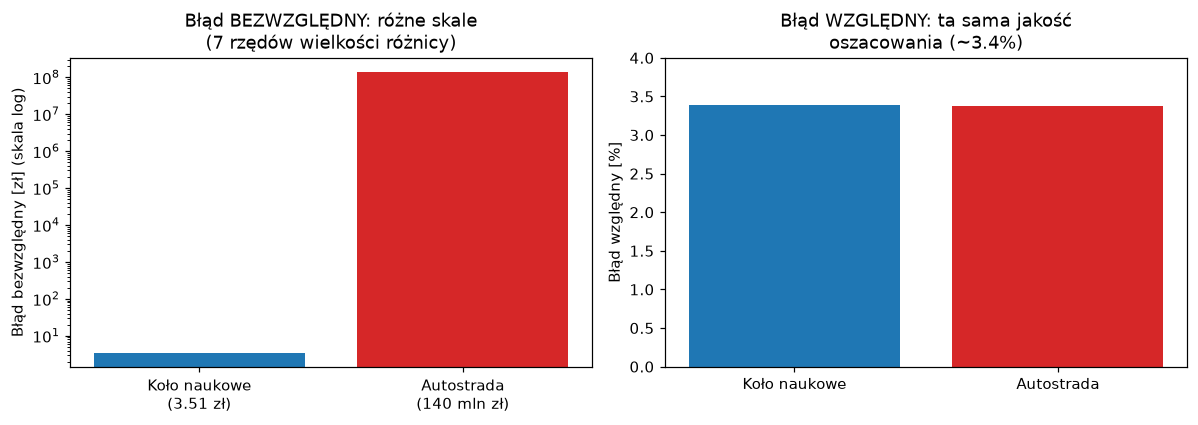

In [6]:
# Graficznie: dwie miary na osobnych osiach.
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

etykiety = ['Koło naukowe\n(3.51 zł)', 'Autostrada\n(140 mln zł)']
ax1.bar(etykiety, [3.51, 140e6], color=['tab:blue', 'tab:red'])
ax1.set_yscale('log')
ax1.set_ylabel('Błąd bezwzględny [zł] (skala log)')
ax1.set_title('Błąd BEZWZGLĘDNY: różne skale\n(7 rzędów wielkości różnicy)')

ax2.bar(['Koło naukowe', 'Autostrada'], [d_kolo*100, d_auto*100], color=['tab:blue', 'tab:red'])
ax2.set_ylabel('Błąd względny [%]')
ax2.set_ylim(0, 4.0)
ax2.set_title('Błąd WZGLĘDNY: ta sama jakość\noszacowania (~3.4%)')
plt.tight_layout(); plt.show()

**Wniosek z tego obrazka jest sercem całego wykładu o błędach:** błąd względny porównuje
*jakość* oszacowania niezależnie od skali (dlatego metody numeryczne wyprowadza się niemal
wyłącznie dla błędów względnych), ale o tym, czy błąd *boli*, decyduje błąd bezwzględny.
Inżynier musi rozumieć obie miary naraz.

## Kiedy którą miarę wygodniej użyć?

Slajdy 5–6 pokazują dwie praktyczne sytuacje, w których wybór miary nie jest kwestią gustu:

1. **Znamy tylko wartość przybliżoną** $\tilde{x}$ (np. odczyt z miernika). Wtedy $\Delta x$
   i $\delta x$ nie dadzą się policzyć dokładnie — ale z definicji $\delta x = \Delta x/x$
   dostajemy *dolne* oszacowanie błędu: skoro $|x| \geq |\tilde{x}| - \Delta x$,
   to błąd względny jest co najmniej $\Delta x / |\tilde{x}|$ minus poprawka.
   W praktyce: przy małych błędach liczy się po prostu $\delta x \approx \Delta x/|\tilde{x}|$.
2. **Wartość prawdziwa jest bliska zera.** Wtedy mianownik $x$ w $\delta x = \Delta x/x$
   robi się mały i błąd względny wybucha — nawet dla niedużego, sensownego błędu bezwzględnego.

Odczyt 0.05 V  ->  błąd względny 20 %
Odczyt 5.00 V  ->  błąd względny 0.20 %


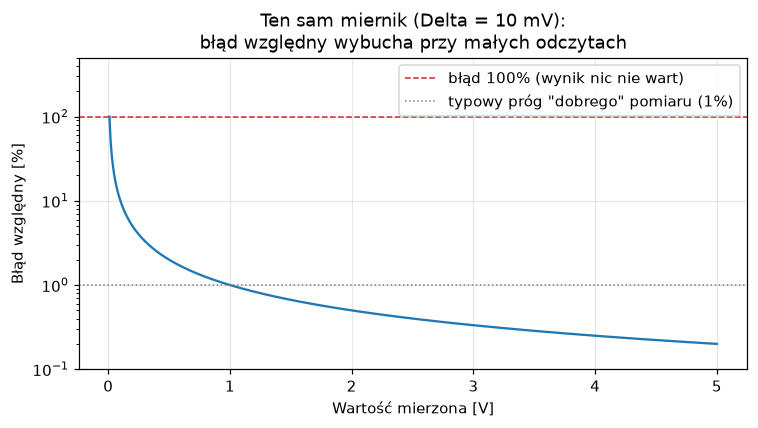

In [8]:
# Demonstracja 2: ta sama niedokładność miernika (Delta = 0.01 V), różne mierzone napięcia.
# Pomiary bliskie zera mają ogromny błąd względny PRZY TYM SAMYM błędzie bezwzględnym.
import numpy as np

Delta_miernika = 0.01                       # V — dokładność woltomierza (stała!)
U_mierzone = np.linspace(0.01, 5, 500)      # odczyty od 10 mV do 5 V
delta_U = Delta_miernika / U_mierzone       # błąd względny każdego odczytu

print("Odczyt 0.05 V  ->  błąd względny %.0f %%" % (100*Delta_miernika/0.05))
print("Odczyt 5.00 V  ->  błąd względny %.2f %%" % (100*Delta_miernika/5.00))

plt.figure(figsize=(7, 4))
plt.plot(U_mierzone, delta_U*100, 'tab:blue')
plt.axhline(100, color='tab:red', ls='--', lw=1, label='błąd 100% (wynik nic nie wart)')
plt.axhline(1, color='gray', ls=':', lw=1, label='typowy próg "dobrego" pomiaru (1%)')
plt.yscale('log'); plt.ylim(1e-1, 500)
plt.xlabel('Wartość mierzona [V]'); plt.ylabel('Błąd względny [%]')
plt.title('Ten sam miernik (Delta = 10 mV):\nbłąd względny wybucha przy małych odczytach')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

# To dlatego woltomierz ma osobne zakresy (mV, V) i dlatego "auto-ranging" ma sens:
# miernik dobiera zakres tak, by odczyt był daleko od zera *w danym zakresie*.

**Zapis przybliżenia w postaci mnożeniowej.** Czasem wygodniej myśleć o wartości przybliżonej
jak o iloczynie wartości dokładnej i czynnika „1 + błąd względny":

$$\tilde{x} = x\,(1 + \delta x)$$

Ten zapis („rachunek epsilonów", wrócimy do niego w ILUSTR 2) sprawia, że błąd względny
staje się *czynnikiem*: dwa kolejne przybliżenia mnożą swoje błędy względne przez siebie,
a błędy rzędu $10^{-16}$ po podniesieniu do kwadratu są kompletnie pomijalne — to pozwala
upraszczać analizy bez utraty ścisłości.

## Najważniejsze wnioski

- Błąd bezwzględny $\Delta x = |\tilde{x}-x|$ — ile jednostek (zł, V, m) nas dzieli od prawdy;
  decyduje o konsekwencjach praktycznych (czy szafa wejdzie do wnęki, czy projekt ma budżet).
- Błąd względny $\delta x = \Delta x/x$ — jak duża to część całej wartości; bezwymiarowy,
  służy do porównywania metod i oszacowań między skalami; to „wspólny język" metod numerycznych.
- Ta sama jakość oszacowania (3.4%) może oznaczać 3.51 zł albo 140 mln zł różnicy.
- Błąd względny wybucha przy wartościach bliskich zeru — wtedy sensowniejszy jest błąd bezwzględny.
- Konwencja wykładowa: błędy podajemy z dokładnością do 2 cyfr znaczących, **w górę**
  (zaniżanie błędu jest niebezpieczne, zawyżanie — tylko nieekonomiczne).
- Wartość przybliżoną zapisujemy też mnożeniowo: $\tilde{x} = x(1+\delta x)$.

In [10]:
# ĆWICZENIE (szkielet — uzupełnij miejsca oznaczone TODO):
#
# 1) Skarbnik koła przeznaczył 250 zł na części, wyszło 262.13 zł.
#    Policz Delta i delta dla tego oszacowania. Ile wynosi delta po konwencji 2 cyfr w górę?
#
# 2) Mierząc rezystor odczytano 970 omów miernikiem o błędzie bezwzględnym 5 omów,
#    a napięcie zasilania 0.004 V oscyloskopem o błędzie bezwzględnym 0.001 V.
#    Który pomiar jest "lepszy" i dlaczego dopiero po policzeniu obu typów błędu
#    wiadomo, że porównanie w ogóle ma sens?
#
# 3) Wykaż na przykładzie numerycznym, że dla x bliskiego zera błąd względny
#    może przekroczyć 100% przy błędzie bezwzględnym równym... połowie dokładności miernika.

Delta_kolo    = None   # TODO: abs(262.13 - 250)
delta_kolo    = None   # TODO: Delta_kolo / 262.13
print("1) Delta = %s zł" % Delta_kolo)
print("   delta = %s" % delta_kolo)
# sprawdzenie: 2 cyfry w górę
# print(blad_2_cyfry_w_gore(delta_kolo*100))

# 2) policz oba błędy względne i porównaj
# delta_R = 5/970
# delta_U = 0.001/0.004
# print(delta_R, delta_U)

1) Delta = None zł
   delta = None


## Wykorzystywane funkcje

- `blad_2_cyfry_w_gore(u)` — konwencja wykładowa: zaokrąglenie błędu w górę do 2 cyfr znaczących
  (`math.log10` znajduje rząd wielkości, `math.ceil` zaokrągla mantysę w górę).
- funkcje biblioteczne: `abs`, `math.log10`, `math.ceil`, `numpy.linspace`, `matplotlib.pyplot`.

## Ćwiczenie — wskazówki

Punkty 1–2 sprowadzają się do podstawienia do definicji. W punkcie 3 nie szukaj wzoru —
po prostu wybierz kilka par $(x, \tilde{x})$ coraz bliższych zera (np. $x=0.001$,
$\tilde{x}=0.0015$) i patrz, jak $\delta x$ rośnie, choć $\Delta x$ stoi w miejscu.
Po rozwiązaniu odkomentuj linie sprawdzające w komórce powyżej.